In [16]:
import numpy as np
from typing import Any
from lf_toolkit.evaluation import Result, Params

In [17]:
import os
import json

cwd = os.getcwd()
dir = os.path.dirname(cwd)
reference_path = os.path.join(dir, "data", "referenceMIDI.json")
response_path = os.path.join(dir, "data", "responseMIDI.json")

with open(reference_path) as f1:
    reference = json.load(f1)

with open(response_path) as f2:
    response = json.load(f2)

# Note Alignment techniques

## DTW

The goal of the note alignment is to find if the student played any missing or extra notes, and which note is missing/extra.


Based on the findings during the project plan phase, DTW is commonly used for alignment. The algorithm can be found in this book (Chpater 3.2 Dynamic Time Warping):
M. Müller, Fundamentals of Music Processing. Cham: Springer International Publishing, 2021, ISBN: 9783030698072. DOI:https://doi.org/10.1007/978-3-030-69808-9.

In general, this DTW algorithm finds an optimal possibly nonlinear alignment between response MIDI sequence to reference MIDI sequence.

Basic approach:
- Evaluating the local cost measure for each pair of elements in the response(X) and reference(Y) sequences. 
- Dynamic programming to find an alignment path between X and Y having minimal overall cost, i.e. DTW distance. The algorithm computes a cumulative distance path, the timestamps of the target MIDI are warped so they perfectly align with the anchor points of the reference MIDI.


However, this basic approach will not correctly handle the missing note case as expected, because it allows a note to match with multiple notes, and each note must be paired. Let's say, there is a note missing in the response, this algorithm tends to match a response note with two reference note, instead of reporting the missing problem.

! need to modify this algorithm to make it handle the missing/extra problem correctly. Cosider analysing each entry of the warping path.

In [ ]:
def compute_cost(note1, note2):
    """
    Compute the local cost measure for each pair of notes.
 
    Only pitch is involved in the cost calculation, since the purpose 
    is to pair up notes with similar pitches.
 
    Args:
        note1: dict with keys "pitch" (int), "start" (float), "duration" (float)
        note2: dict with keys "pitch" (int), "start" (float), "duration" (float)
 
    Returns:
        int: cost value >= 0 (lower means more similar pitch)
    """
    return int(abs(note1["pitch"] - note2["pitch"]))


def note_alignment_DTW(response_notes, ref_notes):
    """
    DTW pipeline: build cost matrix C -> build accumulated cost matrix D 
    -> backtrack to find the optimal warping path
    - the Rows of C and D correspond to response notes
    - the Columns of C and D correspond to reference notes
    
    Args:
        response_notes: The student's response MIDI notes to evaluate
        ref_notes: The reference MIDI note
 
    Returns:
        path: list of (response_idx, ref_idx) pairs — the optimal alignment
        C: local cost matrix
        D: accumulated cost matrix
    """

    N = len(response_notes)
    M = len(ref_notes)

    # step1: Build the local cost matrix C of size (N x M).
    # C[i, j] = note_cost(ref_notes[i], response_notes[j])
    C= np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            C[i, j] = compute_cost(response_notes[i], ref_notes[j])

    # step2: Build the accumulated cost matrix D of size (N+1 x M+1)
    # using small trick for simplifying the initialization
    # D[n, 0] = inf  for n >= 1
    # D[0, m] = inf  for m >= 1
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0
    # for all n in [1..N] and m in [1..M]:
    # D[i, j] = C[i, j] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            D[i, j] = C[i - 1, j - 1] + min(
                D[i - 1, j], # vertical step, multiple response notes are mapped to the same ref note
                D[i, j - 1], # horizontal step, same response note is reused for multiple ref notes
                D[i - 1, j - 1]) # diagonal step

    # step3: Backtrack through the D to find the optimal warping path P
    path = []
    n, m = N, M
    while n > 0 and m > 0:
        path.append((n-1, m-1))
        # Find the minimum cost step
        diag = D[n-1, m-1]
        vertical = D[n-1, m]
        horizontal = D[n, m-1]
        min_step = min(diag, vertical, horizontal)
        if min_step == vertical:
            n -= 1
        elif min_step == horizontal:
            m -= 1
        else: # diagonal step
            n -= 1
            m -= 1
    # Reverse to get the path from start to end
    path.reverse()  

    return path, C, D


def path_classification(path, C):
    """
    Classify the each entry of the alignment path into:
    - correct: response pitch matches reference pitch (cost = 0)
    - wrong: response pitch differs from reference pitch, but all the parings are one-to-one (cost > 0)
    - missing: same response pitch is mapped to multiple reference pitches 
    - extra: multiple response pitches are mapped to the same reference pitch
 
    Args:   
    path: list of (response_idx, reference_idx) pairs from the backtrack warping path
    C: local cost matrix (N x M)

    Returns:
        list of event dicts, each one of:
            {'type': 'match' or 'replacement' or 'missing' or 'extra', 
            'response_idx': int, 'ref_idx': int, 'cost': int}
    """

Evaluation

In [ ]:
def evaluate_note_pair(response_note, ref_note, ref_idx,
                       timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Evaluate a single aligned note pair and return feedback.
 
    Args:
        response_note: student's note dict
        ref_note: reference note dict
        ref_idx: 1-based display index (based on ref position)
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        is_correct (bool), feedback (list of str)
    """
    feedback = []
    is_correct = True
 
    # Pitch check
    if response_note["pitch"] != ref_note["pitch"]:
        is_correct = False
        feedback.append(
            f"Note {ref_idx}: wrong pitch — expected {ref_note['pitch']}, "
            f"played {response_note['pitch']}."
        )
 
    # Timing check
    timing_diff = abs(response_note["start"] - ref_note["start"])
    if timing_diff > timing_tolerance:
        is_correct = False
        feedback.append(f"Note {ref_idx}: difference in start time: {timing_diff:.2f}s.")
 
    # Duration check
    duration_diff = abs(response_note["duration"] - ref_note["duration"])
    if duration_diff > duration_tolerance:
        is_correct = False
        feedback.append(f"Note {ref_idx}: difference in duration: {duration_diff:.2f}s.")
 
    if is_correct:
        feedback.append(f"Note {ref_idx} (with pitch {ref_note['pitch']}) is correct.")
 
    return is_correct, feedback

In [ ]:
def comparison(response, ref,
                   timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Compare student MIDI against reference MIDI after DTW-based alignment.
 
    Args:
        response: The student's response MIDI
        ref: The reference MIDI
        timing_tolerance:   seconds
        duration_tolerance: seconds
 
    Returns:
        all_correct (bool), feedback (list of str)
    """
    response_notes = response["notes"]
    ref_notes = ref["notes"]
 
    # Align using DTW — response first, ref second
    path, C, D = note_alignment_DTW(response_notes, ref_notes)
 
    feedback = []
    all_correct = True
    
    for response_idx, ref_idx in path:
        is_correct, feedback = evaluate_note_pair(
            response_notes[response_idx], ref_notes[ref_idx],
            ref_idx=ref_idx + 1,
            timing_tolerance=timing_tolerance,
            duration_tolerance=duration_tolerance,
        )
        if not is_correct:
            all_correct = False
        feedback.extend(feedback)
 
    return all_correct, feedback

In [ ]:
def evaluation_function(response: Any, answer: Any, params: Params) -> Result:
    """
    Entry point for Lambda Feedback.
 
    Args:
        response: student MIDI dict
        answer:   reference MIDI dict
        params:   optional extra parameters
 
    Returns:
        Result with is_correct and feedback string
    """
    all_correct, feedback = comparison(response, answer)
    return Result(
        is_correct=all_correct,
        feedback_items=[("feedback", "\n".join(feedback))]
    )

In [ ]:
is_correct, feedbacks = comparison(
    response,
    reference
)

print(is_correct)

for feedback in feedbacks:
    print(feedback)

False
Note 1 (with pitch 60) is correct.
Note 2: wrong pitch — expected 62, played 63.
Note 3: difference in start time: 0.15s.
Note 4: difference in duration: 0.20s.
Note 5: wrong pitch — expected 67, played 65.
Note 5: difference in start time: 0.70s.
Note 5: difference in duration: 0.20s.


note5 should be a missing pitch!! Need to check the DTW algorithm!

## Edit Distance

a simplified version of this is applied here: https://www.math.univ-toulouse.fr/~mongeau/music.pdf 

Unlike standard DTW where off-diagonal moves has no cost and every note must be aligned to another, the Edit-distance approach allows a note to be explicitly left unaligned at the cost of gap_penalty, i.e. insertion represents an extra note, deletion represents a missing note, the moving direction during backtracking has an unambiguous meaning (diagonal = match/replacement, vertical = extra, horizontal = missing), we can classify each operation directly during backtracking.

In [18]:
def compute_cost(note1, note2):
    """
    Cost of aligning (replacing) one note with another, based on pitch.
 
    cost = 0: pitches are identical (a 'match'). 
    cost > 0: different pitches (a 'replacement')
 
    Args:
        note1: dict with keys "pitch" (int), "start" (float), "duration" (float)
        note2: dict with keys "pitch" (int), "start" (float), "duration" (float)
 
    Returns:
        int: cost value >= 0 (lower means more similar pitch)
    """
    return int(abs(note1["pitch"] - note2["pitch"]))


def note_alignment_ED(response_notes, ref_notes, gap_penalty=6):
    """
    Align notes using edit distance (ED). 
    The ED allows for insertions and deletions, which can be useful for 
    evaluating musical practice containing missing/extra notes.
    
    Args:
        response_notes: The student's response MIDI notes to evaluate
        ref_notes: The reference MIDI note
        gap_penalty: cost of leaving a note unaligned (insertion/deletion)
 
    Returns:
        operations: list of transformation ops dicts, in order from first note to last:
            {'type': 'match' or 'replacement' or 'missing' or 'extra', 
            'response_idx': int or None, 
            'ref_idx': int or None, 
            'cost': int}
        D: accumulated cost matrix, shape (N+1, M+1)
    """
    # the rows of D correspond to response notes
    N = len(response_notes)
    # the columns of D correspond to reference notes
    M = len(ref_notes)

    # Build the accumulated cost matrix D of size (N+1 x M+1)
    D = np.zeros((N + 1, M + 1), dtype=int)
    # Boundary conditions: aligning against an empty sequence means every note
    # is unaligned, so the cost is n (or m) times the gap penalty.
    for n in range(1, N + 1):
        D[n, 0] = n * gap_penalty # n extra response notes
    for m in range(1, M + 1):
        D[0, m] = m * gap_penalty # m missing ref notes
    # Recursion (accumulated cost / score matrix D):
    for n in range(1, N + 1):
        for m in range(1, M + 1):
            replace_cost = compute_cost(response_notes[n-1], ref_notes[m-1])
            D[n, m] = min(
                D[n-1, m-1] + replace_cost, # diagonal: match or replacement
                D[n-1, m] + gap_penalty, # vertical: extra note response[n-1]
                D[n, m-1] + gap_penalty, # horizontal: missing response for ref[m-1]
            )

    # Backtrack, classify each transformation ops based on movement direction in D
    operations = []
    n, m = N, M
    while n > 0 or m > 0:
        # boundary conditions: if we are at the most top row or left column, we can only move in one direction
        # at the top row, only horizontal moves possible
        if n == 0: 
            # missing response for ref[m-1] (deletion)
            operations.append({"type": "missing", "response_idx": None,
                            "ref_idx": m - 1, "cost": gap_penalty})
            m -= 1
        # at the most left column, only vertical moves possible
        elif m == 0: 
            # extra note response[n-1] (insertion)
            operations.append({"type": "extra", "response_idx": n - 1,
                            "ref_idx": None, "cost": gap_penalty})
            n -= 1
        # for all other cases, we can move in any direction (diagonal, vertical, horizontal)
        else:
            replace_cost = compute_cost(response_notes[n-1], ref_notes[m-1])
            diag = D[n-1, m-1] + replace_cost # diagonal: match or replacement
            up = D[n-1, m] + gap_penalty # vertical: extra note response[n-1]
            left = D[n, m-1] + gap_penalty # horizontal: missing response for ref[m-1]
            min_cost = min(diag, up, left) # find the minimum cost step
            # classify the transformation ops based on the minimum cost step
            if min_cost == diag: # diagonal -> two notes are aligned (match/replacement)
                operations.append({
                    "type": "match" if replace_cost == 0 else "replacement",
                    "response_idx": n - 1,
                    "ref_idx": m - 1,
                    "cost": replace_cost,
                })
                n, m = n - 1, m - 1
            elif min_cost == up: # vertical -> response[n-1] is extra (insertion)
                operations.append({"type": "extra", "response_idx": n - 1,
                                "ref_idx": None, "cost": gap_penalty})
                n -= 1
            else: # horizontal -> response is missing for ref[m-1] (deletion)
                operations.append({"type": "missing", "response_idx": None,
                                "ref_idx": m - 1, "cost": gap_penalty})
                m -= 1
 
    operations.reverse() # reverse the operations to get them in order from first note to last
    return operations, D

TODO: The gap_penaulty need careful consideration! To be modified.

# Feedback generation

In [19]:
def generate_feedback(operations, response_notes, ref_notes,
                       timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Evaluate the response MIDI and return feedback.
    For 'match'/'replacement' operations, checks pitch, timing, and duration
    of the aligned pair. 
    For 'missing'/'extra' operations, reports the note directly
 
    Args:
        operations: list of transformation ops dicts
        response_notes: list of note dicts from student's performance
        ref_notes: list of note dicts from reference performance
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        is_correct (bool), feedback (list of str)
    """

    feedback = []
    is_correct = True

    for op in operations:
        if op["type"] in ("match", "replacement"):
            response_note = response_notes[op["response_idx"]]
            ref_note = ref_notes[op["ref_idx"]]
            ref_idx = op["ref_idx"] + 1   # 1-based for display
            correct_note = True

            # Pitch check
            if response_note["pitch"] != ref_note["pitch"]:
                correct_note = False
                feedback.append(
                    f"Note {ref_idx}: wrong pitch — expected {ref_note['pitch']}, "
                    f"played {response_note['pitch']}."
                )
        
            # Timing check
            timing_diff = abs(response_note["start"] - ref_note["start"])
            if timing_diff > timing_tolerance:
                correct_note = False
                feedback.append(f"Note {ref_idx}: difference in start time: {timing_diff:.2f}s.")
        
            # Duration check
            duration_diff = abs(response_note["duration"] - ref_note["duration"])
            if duration_diff > duration_tolerance:
                correct_note = False
                feedback.append(f"Note {ref_idx}: difference in duration: {duration_diff:.2f}s.")

            if correct_note:
                feedback.append(f"Note {ref_idx} (pitch {ref_note['pitch']}) is correct.")
            else:
                is_correct = False
        
        elif op["type"] == "missing":
            is_correct = False
            ref_idx = op["ref_idx"]
            feedback.append(
                f"Note {ref_idx + 1} (pitch {ref_notes[ref_idx]['pitch']}) "
                f"is missing in your performance."
            )
 
        elif op["type"] == "extra":
            is_correct = False
            response_note = response_notes[op["response_idx"]]
            feedback.append(
                f"Extra note played: pitch {response_note['pitch']} "
                f"at t={response_note['start']:.2f}s (not in reference)."
            )
 
    return is_correct, feedback


def compare_performance(responseMIDI, refMIDI, gap_penalty=6,
                        timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Compare student MIDI against reference MIDI
 
    Args:
        responseMIDI: student's response MIDI dict
        refMIDI: reference MIDI dict
        gap_penalty: cost of leaving a note unaligned
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        all_correct (bool), feedback (list of str)
    """
    response_notes = responseMIDI["notes"]
    ref_notes      = refMIDI["notes"]
 
    # Step 1: align using edit distance with gap penalty,
    # emitting match/replacement/missing/extra operations directly
    operations, D = note_alignment_ED(response_notes, ref_notes, gap_penalty)
 
    # Step 2: turn the alignment operations into feedback messages
    all_correct, feedback = generate_feedback(
        operations, response_notes, ref_notes,
        timing_tolerance=timing_tolerance,
        duration_tolerance=duration_tolerance,
    )
 
    return all_correct, feedback, operations, D

In [20]:
def evaluation_function(
    response: Any,
    answer: Any,
    params: Params,
) -> Result:
    """
    Function used to evaluate a student response.
    ---
    The handler function passes three arguments to evaluation_function():

    - `response` which are the answers provided by the student.
    - `answer` which are the correct answers to compare against.
    - `params` which are any extra parameters that may be useful,
        e.g., error tolerances.

    The output of this function is what is returned as the API response
    and therefore must be JSON-encodable. It must also conform to the
    response schema.

    Any standard python library may be used, as well as any package
    available on pip (provided it is added to requirements.txt).

    The way you wish to structure you code (all in this function, or
    split into many) is entirely up to you. All that matters are the
    return types and that evaluation_function() is the main function used
    to output the evaluation response.
    """
    all_correct, feedback = compare_performance(response, answer)

    return Result(
    is_correct=all_correct,
    feedback_items=[("feedback", "\n".join(feedback))]
    )

In [23]:
is_correct, feedbacks, operations, D = compare_performance(
    response,
    reference
)

print(is_correct)

for feedback in feedbacks:
    print(feedback)

False
Note 1 (pitch 60) is correct.
Note 2: wrong pitch — expected 62, played 63.
Note 3: difference in start time: 0.15s.
Note 4: difference in duration: 0.20s.
Note 5 (pitch 67) is missing in your performance.


#### TODO:

break `generate_feedback` into three functions, one for note_level_feedback, one for stats, one for feedback message. 

feedback = {

    "stats": {

        "pitch_all_correct": bool,         
        "timing_all_correct": bool,        
        "duration_all_correct": bool,

        "total_notes_in_reference": int,             
        "total_notes_missing": int,              
        "total_notes_extra": int,
        "total_notes_wrong_pitch": int,
        "total_notes_wrong_timing": int,
        "total_notes_wrong_duration": int,
        "total_notes_correct": int,
    },

    "note_level_feedback": [
        
        {
            "reference_index": int,
            "response_index": int,
            "operation_type": str,             # "match" / "replacement" / "missing" / "extra"
            "pitch_correct": bool,
            "timing_correct": bool,
            "duration_correct": bool,
            "pitch_diff": int,        
            "timing_diff": float,      
            "duration_diff": float,    
        },
        ...
    ],

    "feedback_message": str,
}

In [ ]:
def compute_stats(operations, response_notes, ref_notes):
    """
    Compute summary counts and correctness booleans from note-level feedback.
 
    Args:
        operations : list of operation (match/replacement/missing/extra)
        response_notes : list of note dicts from response
        ref_notes : list of note dicts from reference 
 
    Returns:
        stats : dict with keys:
            "pitch_all_correct"          -> bool
            "timing_all_correct"         -> bool
            "duration_all_correct"       -> bool
            "total_notes_in_reference"   -> int
            "total_notes_missing"        -> int   (reference notes not played)
            "total_notes_extra"          -> int   (response notes not in reference)
            "total_notes_wrong_pitch"    -> int   (paired notes where pitch_correct=False)
            "total_notes_wrong_timing"   -> int   (paired notes where timing_correct=False)
            "total_notes_wrong_duration" -> int   (paired notes where duration_correct=False)
            "total_notes_correct"        -> int   (paired notes correct on all three dimensions)
    """
    pass


def note_level_feedback(operations, response_notes, ref_notes):
    """
    Build a list of note-level feedback dicts.

    Args:
        operations : list of operation (match/replacement/missing/extra)
        response_notes : list of note dicts from response
        ref_notes : list of note dicts from reference 
 
    Returns:
        note_level_feedback : list of dicts, each dict contains:
            "reference_index"  -> int (1-based) or None if operation_type = extra
            "response_index"   -> int (1-based) or None if operation_type = missing
            "operation_type"   -> str: "match", "replacement", "missing", or "extra"
            "pitch_correct"    -> bool
            "timing_correct"   -> bool
            "duration_correct" -> bool
            "pitch_diff"       -> int
            "timing_diff"      -> float
            "duration_diff"    -> float
    """
    pass


def generate_feedback_message(note_level_feedback, stats):
    """
    Generate a human-readable feedback string for the student.
 
    Args:
        note_level_feedback : list
        stats : dict
 
    Returns:
        feedback_message : str 
    """
    pass

### Visualisation

In [30]:
# use ChatGPT to help with the code for the cost matrix and alignment arrows, wrote the code myself

import matplotlib.pyplot as plt

def plot_cost_matrix(D, operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(8, 6))
 
    im = ax.imshow(D, origin="upper", aspect="auto", cmap="gray_r")
    plt.colorbar(im, ax=ax, label="Accumulated cost")
 
    # Annotate every cell with its value
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            ax.text(j, i, f"{D[i, j]:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if D[i, j] > D.max() * 0.5 else "black")
 
    # Reconstruct path coordinates from operations
    # D has a padding row/column at index 0, so shift by +1
    path_rows, path_cols = [0], [0] # start at (0,0) — the base case
    for op in operations:
        if op["type"] in ("match", "replacement"):
            path_rows.append(op["response_idx"] + 1)
            path_cols.append(op["ref_idx"] + 1)
        elif op["type"] == "extra":
            path_rows.append(op["response_idx"] + 1)
            path_cols.append(path_cols[-1]) # ref col stays the same
        elif op["type"] == "missing":
            path_rows.append(path_rows[-1]) # response row stays the same
            path_cols.append(op["ref_idx"] + 1)
 
    ax.plot(path_cols, path_rows, "ro-", markersize=10, linewidth=2,
            label="Optimal alignment path")
 
    # Axis labels — empty string for the padding row/col
    ref_labels = [""] + [f"$x_{j}$" for j in range(len(ref_notes))]
    response_labels = [""] + [f"$y_{i}$" for i in range(len(response_notes))]
    ax.set_xticks(range(len(ref_labels)))
    ax.set_xticklabels(ref_labels, fontsize=8)
    ax.set_yticks(range(len(response_labels)))
    ax.set_yticklabels(response_labels, fontsize=8)
    ax.set_xlabel("Reference")
    ax.set_ylabel("Response")
    ax.set_title(f"Accumulated Cost Matrix D")
    ax.legend(loc="upper left", fontsize=8)
 
    plt.tight_layout()
    # plt.savefig("edit_distance_matrix.png", dpi=150, bbox_inches="tight")
    # print("Saved: edit_distance_matrix.png")
    plt.show()
 
 
def plot_alignment_arrows(operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(12, 3))

    N = len(response_notes)
    M = len(ref_notes)

    # Draw boxes for ref notes (top row, y=1) and response notes (bottom row, y=0)
    for j, note in enumerate(ref_notes):
        ax.add_patch(plt.Rectangle((j - 0.4, 0.75), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(j, 1.0, f"$x_{{{j+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)

    for i, note in enumerate(response_notes):
        ax.add_patch(plt.Rectangle((i - 0.4, -0.25), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(i, 0.0, f"$y_{{{i+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)

    # Draw arrows between aligned pairs
    for op in operations:
        if op["type"] in ("match", "replacement"):
            colour = "green" if op["type"] == "match" else "red"
            ax.annotate("",
                xy =(op["response_idx"], 0.25),
                xytext = (op["ref_idx"], 0.75),
                arrowprops = dict(arrowstyle="<->", color=colour,
                                lw=1.5, mutation_scale=12),
            )
        elif op["type"] == "missing":
            j = op["ref_idx"]
            ax.text(j, 1.45, "missing", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")
        elif op["type"] == "extra":
            i = op["response_idx"]
            ax.text(i, -0.45, "extra", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")

    ax.text(-0.8, 1.0, "Sequence X\n(ref)", ha="right", va="center", fontsize=9)
    ax.text(-0.8, 0.0, "Sequence Y\n(response)", ha="right", va="center", fontsize=9)

    ax.set_xlim(-1.2, max(N, M) - 0.4)
    ax.set_ylim(-0.7, 1.7)
    ax.axis("off")
    plt.tight_layout()
    # plt.savefig("edit_distance_alignment.png", dpi=150, bbox_inches="tight")
    # print("Saved: edit_distance_alignment.png")
    plt.show()

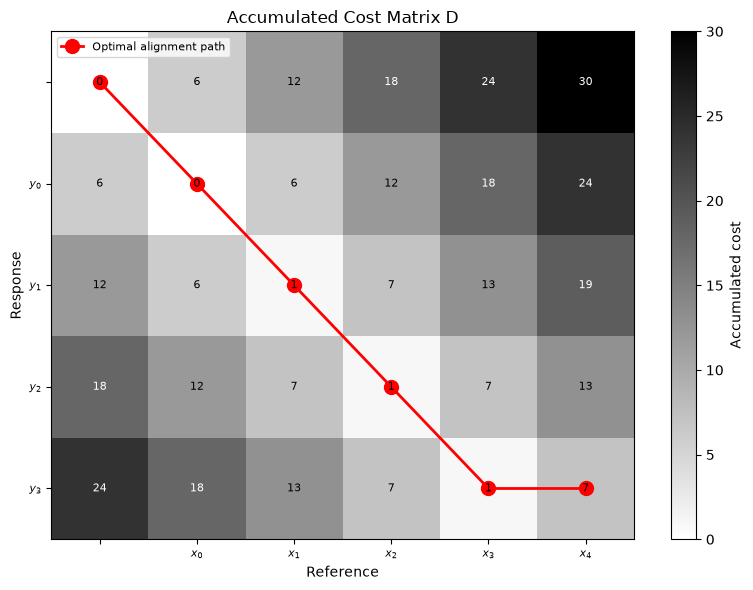

In [31]:
plot_cost_matrix(D, operations, response["notes"], reference["notes"])

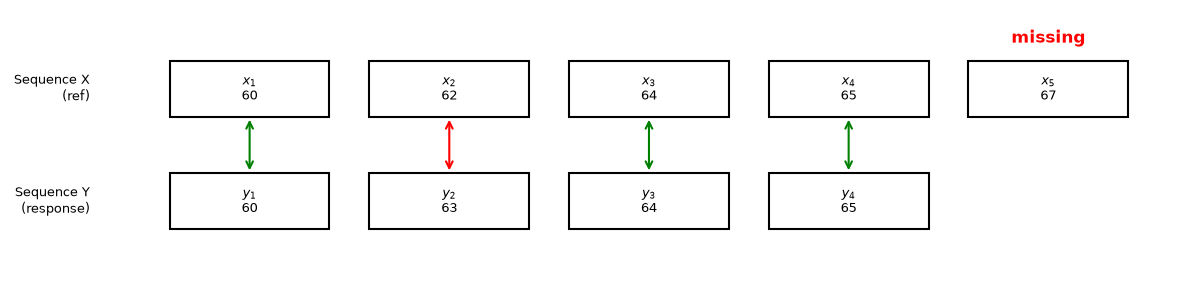

In [32]:
plot_alignment_arrows(operations, response["notes"], reference["notes"])